In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from copy import copy
import scipy
import pynumdiff

os.environ["JULIA_PROJECT"] = ""
os.environ["PYTHON_JULIAPKG_USE_CACHE"] = "false"

from pysr import PySRRegressor
import pysindy
import pynumdiff
from scipy.signal import savgol_filter

2025-10-24 16:43:01,800 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2025-10-24 16:43:01,801 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2025-10-24 16:43:01,802 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


0.01
[9.0069813  9.10373537 9.17907046 ... 9.80442904 9.80117321 9.80377265]
[ 8.32995401  8.22386937  8.12419689 ...  0.01887003 -0.05660676
 -0.14945704]


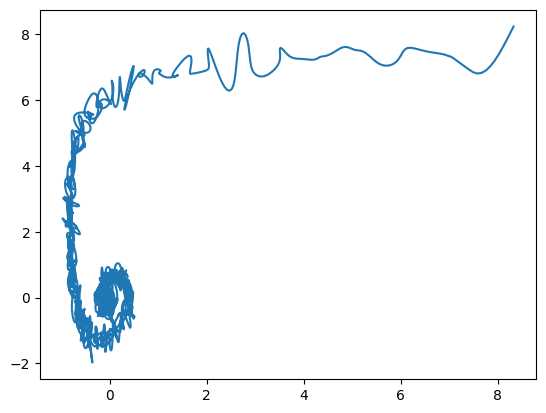

In [2]:
data = pd.read_csv('datasets/bact_res_SNR50.csv')

h=data.t.to_numpy()[1] - data.t.to_numpy()[0]
print(h)
print(data.x.to_numpy())
x_hat, dxdt_hat = pynumdiff.polydiff(data.x.to_numpy(), dt=h, params=[2,20,20])
print(dxdt_hat)
y_hat, dydt_hat = pynumdiff.polydiff(data.y.to_numpy(), dt=h, params=[2,20,20])

plt.plot(dxdt_hat,dydt_hat)

Compiling Julia backend...
2025-10-24 16:43:05,752 [INFO] Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 6.070e+04
Progress: 577 / 8000 total iterations (7.213%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.307e+00  0.000e+00  target = 0.027542
3           1.148e+00  6.472e-02  target = 16.383 / y
4           3.165e-01  1.289e+00  target = 18960 / cube(y)
5           2.789e-01  1.266e-01  target = (112.9 / y) - 2.5305
6           1.797e-01  4.397e-01  target = (20788 / cube(y)) + -0.3822
7           7.270e-02  9.048e-01  target = -3.0976 - (-1540.8 / (x * y))
9           5.653e-02  1.257e-01  target = (-1991.6 / (y * (-3.077 - x))) - 3.1212
11          3.858e-02  1.911e-01  target = -8.3498 - ((0.0022016 / ((y * -0.37698) - x)...
                                           ) * 1.0962e+05)
15          3.537e-02  2.168e-02  target = ((x / -6.6997) 

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        0.027542256   
	1         0.064720                                      16.383347 / y   
	2         1.288500                                18959.078 / cube(y)   
	3         0.126595                        (112.89907 / y) - 2.5304513   
	4         0.454379                   cube(27.952156 / y) + -0.4029471   
	5         1.289475                   (136.5905 / y) - (x * 0.2715929)   
	6         0.118114   -8.409402 - (241.3292 / ((y * -0.37259617) - x))   
	7         0.004039  -8.818548 - (260.56522 / ((y * -0.37306738) - ...   
	8         0.034112  (x / -6.28345) + (-3.7880821 - (272.76755 / ((...   
	9   >>>>  0.771557  ((-157.58615 / x) + -39.728394) - (1901.1547 /...   
	10        0.099342  ((-19.523016 - (788.55347 / ((y * -0.10341285)...   
	11        0.033900  ((-19.958246 - (788.5426 / ((y * -0.102043204)...   
	12      

[ Info: Started!



Expressions evaluated per second: 6.280e+04
Progress: 621 / 8000 total iterations (7.763%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.155e+00  0.000e+00  target = 1.27
3           1.355e+00  7.565e-01  target = x + -9.9719
5           1.277e+00  2.994e-02  target = (y * -0.24459) + 12.891
7           5.077e-02  1.612e+00  target = (y * (-1.9422 / x)) + 9.9113
9           5.015e-02  6.052e-03  target = (y * (-2.0341 / (x + 0.37111))) - -10.009
14          5.015e-02  3.397e-06  target = (((-2.0341 / (x + 0.37111)) + (66.26 / exp(y...
                                           ))) * y) - -10.009
15          5.015e-02  8.667e-05  target = (((-2.0278 / (x + 0.34994)) + (cube(y) / exp...
                                           (y))) * y) - -9.9992
17          5.012e-02  3.244e

[ Info: Final population:
[ Info: Results saved to:


  - outputs/20251024_164413_Vlaqum/hall_of_fame.csv


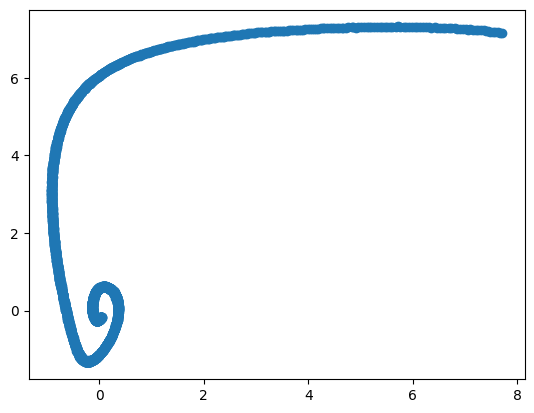

In [3]:
model = PySRRegressor(
    populations=8,                   # Fewer populations (parallel groups)
    population_size=50,              # 30 individuals per population
    ncycles_per_iteration=50,       # 100 generations between migrations
    niterations=1000,                 # Total 100 migrations → ~10,000 generations
    early_stop_condition="stop_if(loss, complexity) = loss < 1e-6 && complexity < 15",
    timeout_in_seconds=60 * 60 * 12,      # 1 hour wall-time limit
    maxsize=30,
    maxdepth=10,
    model_selection="best",   # or 'accuracy'
    binary_operators=["*", "+", "-", "/"],
    unary_operators=["square", "cube", "exp"],
    constraints={
        "/": (-1, 9),
        "square": 9,
        "cube": 9,
        "exp": 9,
    },
    # ^ Limit the complexity within each argument.
    # "inv": (-1, 9) states that the numerator has no constraint,
    # but the denominator has a max complexity of 9.
    # "exp": 9 simply states that `exp` can only have
    # an expression of complexity 9 as input.
    nested_constraints={
        "square": {"square": 1, "cube": 1, "exp": 0},
        "cube": {"square": 1, "cube": 1, "exp": 0},
        "exp": {"square": 1, "cube": 1, "exp": 0},
    }
    # ^ Define operator for SymPy as well
)

X = data[['x','y']]

model.fit(X, dxdt_hat)

p_x = model.predict(X)

print(model)

model.fit(X, dydt_hat)

p_y = model.predict(X)

print(model)

plt.scatter(p_x,p_y)